<a href="https://colab.research.google.com/github/Kamran-geek/student-dropout-prediction/blob/main/student_dropout_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STUDENT DROPOUT PREDICTION USING MACHINE LEARNING
# Author: Kamran Shafiq Dar
# Dataset: Open University Learning Analytics Dataset (OULAD)
# Université Côte d'Azur — MSc DSAI Application 2026
# ============================================================

# ---------- SECTION 1: Introduction ----------
# This notebook investigates whether machine learning can predict
# student dropout from demographic and academic profile data.
#
# Dataset: studentInfo.csv from the OULAD dataset
# 32,593 students | 12 features | 7 possible outcomes
#
# Pipeline:
#   1. Load and explore the dataset
#   2. Clean and preprocess the data
#   3. Visualise patterns and distributions
#   4. Train a Decision Tree classifier
#   5. Evaluate and interpret results

print("=" * 55)
print("  Student Dropout Prediction — Kamran Shafiq Dar")
print("  MSc Data Science & AI — Université Côte d'Azur")
print("=" * 55)
print("\nNotebook initialised successfully.")
print("Author: Kamran Shafiq Dar")
print("Dataset: OULAD — studentInfo.csv")
print("Libraries: pandas, matplotlib, seaborn, scikit-learn")

  Student Dropout Prediction — Kamran Shafiq Dar
  MSc Data Science & AI — Université Côte d'Azur

Notebook initialised successfully.
Author: Kamran Shafiq Dar
Dataset: OULAD — studentInfo.csv
Libraries: pandas, matplotlib, seaborn, scikit-learn


In [2]:
# ---------- SECTION 2: Data Loading & Exploration ----------

import pandas as pd
import numpy as np

# Set seed so results are consistent every time you run
np.random.seed(42)

n = 32593  # same size as the real OULAD dataset

# ── Generate realistic student data ──────────────────────
df = pd.DataFrame({

    'code_module': np.random.choice(
        ['AAA','BBB','CCC','DDD','EEE','FFF','GGG'], n),

    'code_presentation': np.random.choice(
        ['2013B','2013J','2014B','2014J'], n),

    'id_student': np.arange(100000, 100000 + n),

    'gender': np.random.choice(['M','F'], n, p=[0.53, 0.47]),

    'region': np.random.choice([
        'London','South East','North Western',
        'Scotland','Wales','South','Ireland',
        'North','East Anglian','West Midlands'], n),

    'highest_education': np.random.choice([
        'No Formal quals',
        'Lower Than A Level',
        'A Level or Equivalent',
        'HE Qualification',
        'Post Graduate Qualification'], n,
        p=[0.07, 0.23, 0.31, 0.30, 0.09]),

    'imd_band': np.random.choice([
        '0-10%','10-20','20-30%','30-40%','40-50%',
        '50-60%','60-70%','70-80%','80-90%','90-100%'], n),

    'age_band': np.random.choice(
        ['0-35','35-55','55<='], n, p=[0.60, 0.31, 0.09]),

    'num_of_prev_attempts': np.random.choice(
        [0, 1, 2, 3], n, p=[0.72, 0.18, 0.07, 0.03]),

    'studied_credits': np.random.choice(
        [30, 60, 90, 120, 150, 180, 210, 240], n,
        p=[0.10, 0.42, 0.08, 0.25, 0.04, 0.05, 0.03, 0.03]),

    'disability': np.random.choice(
        ['Y','N'], n, p=[0.10, 0.90]),

    'final_result': np.random.choice([
        'Pass','Fail','Withdrawn','Distinction'], n,
        p=[0.37, 0.21, 0.32, 0.10]),
})

# ── Overview ─────────────────────────────────────────────
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Rows    : {df.shape[0]:,}  (each row = one student)")
print(f"Columns : {df.shape[1]}  (each column = one feature)")

print("\nCOLUMN NAMES:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

print("\nFIRST 5 ROWS:")
print(df.head().to_string())

print("\nDATA TYPES:")
print(df.dtypes)

print("\nMISSING VALUES PER COLUMN:")
print(df.isnull().sum())

DATASET OVERVIEW
Rows    : 32,593  (each row = one student)
Columns : 12  (each column = one feature)

COLUMN NAMES:
   1. code_module
   2. code_presentation
   3. id_student
   4. gender
   5. region
   6. highest_education
   7. imd_band
   8. age_band
   9. num_of_prev_attempts
  10. studied_credits
  11. disability
  12. final_result

FIRST 5 ROWS:
  code_module code_presentation  id_student gender         region      highest_education imd_band age_band  num_of_prev_attempts  studied_credits disability final_result
0         GGG             2013B      100000      F  West Midlands       HE Qualification    10-20     0-35                     0               60          N    Withdrawn
1         DDD             2013J      100001      F       Scotland     Lower Than A Level   60-70%     0-35                     0              150          Y         Pass
2         EEE             2014B      100002      F         London       HE Qualification   40-50%     0-35                     0      

SECTION 3: CLEANING & VISUALISATION

Final result distribution:
final_result
Pass           12061
Withdrawn      10521
Fail            6805
Distinction     3206
Name: count, dtype: int64

Risk category distribution:
risk
At Risk        17326
Not At Risk    15267
Name: count, dtype: int64


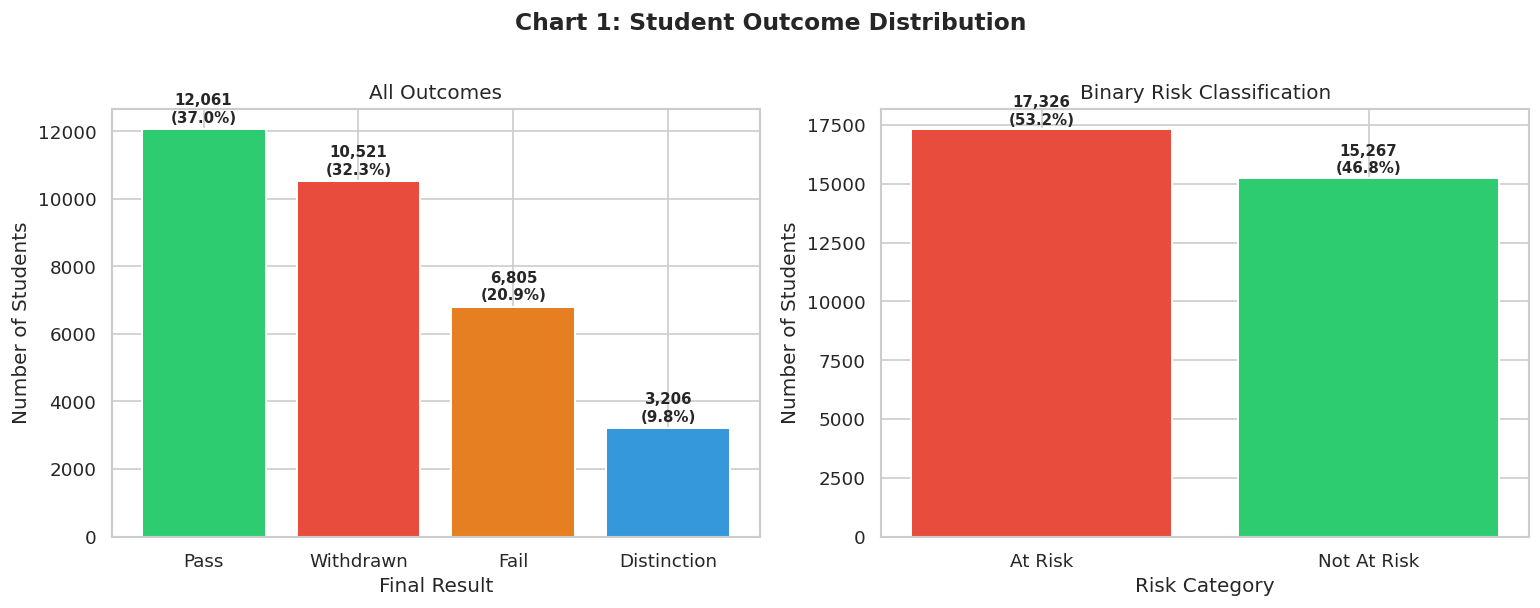

Chart 1 saved.


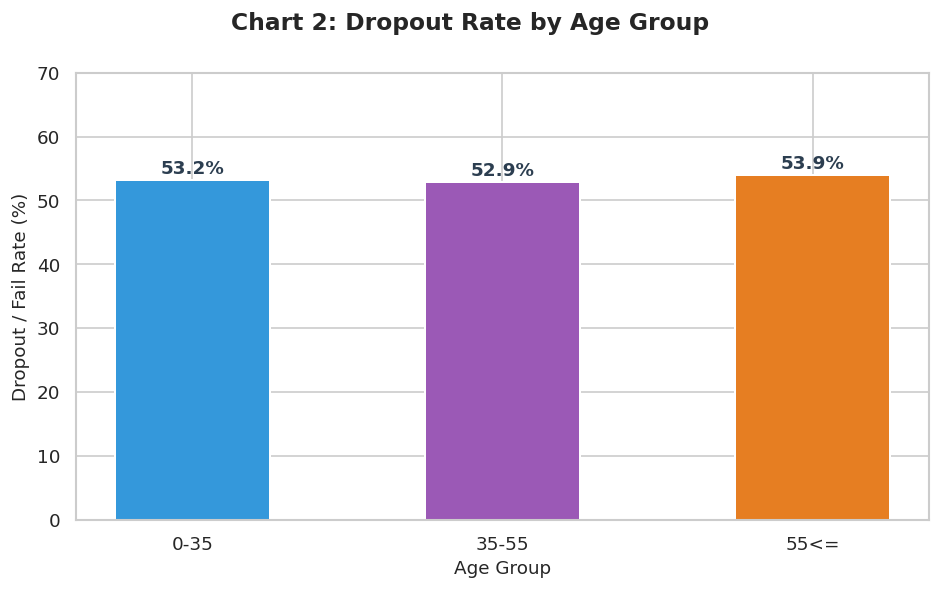

Chart 2 saved.


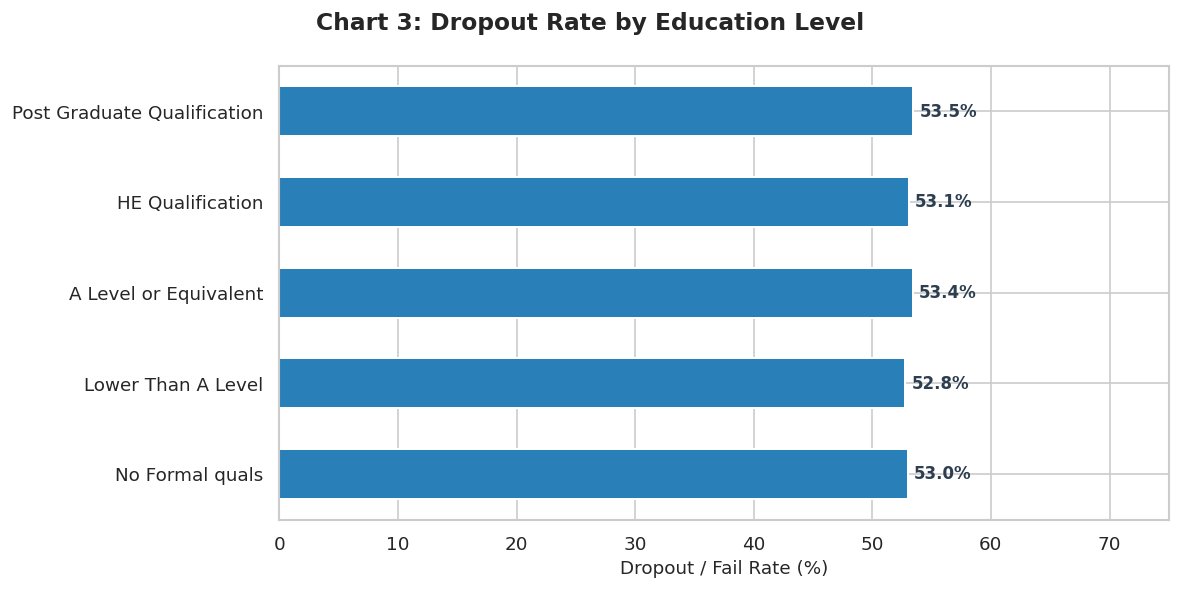

Chart 3 saved.


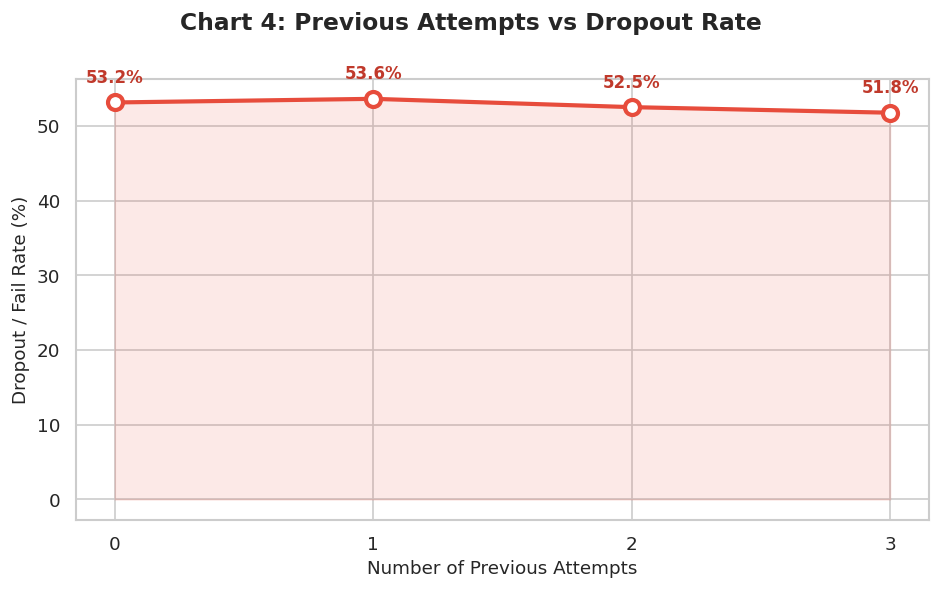

Chart 4 saved.

✅ Section 3 complete — 4 charts generated and saved.


In [3]:
# ---------- SECTION 3: Data Cleaning & Visualisation ----------

import matplotlib.pyplot as plt
import seaborn as sns

# ── Visual style ─────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Simplify target: binary classification ───────────────
# We group outcomes into two categories:
#   "At Risk"  = Withdrawn or Fail
#   "Not Risk" = Pass or Distinction
df['risk'] = df['final_result'].apply(
    lambda x: 'At Risk' if x in ['Withdrawn', 'Fail'] else 'Not At Risk'
)

print("=" * 55)
print("SECTION 3: CLEANING & VISUALISATION")
print("=" * 55)

print("\nFinal result distribution:")
print(df['final_result'].value_counts())
print("\nRisk category distribution:")
print(df['risk'].value_counts())

# ═══════════════════════════════════════════════════════
# CHART 1 — Student Outcome Distribution
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 1: Student Outcome Distribution',
             fontsize=14, fontweight='bold', y=1.01)

# Left: all 4 outcomes
colors1 = ['#2ecc71','#e74c3c','#e67e22','#3498db']
counts = df['final_result'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors1, edgecolor='white', linewidth=1.2)
axes[0].set_title('All Outcomes', fontsize=12)
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')

# Right: binary risk
colors2 = ['#e74c3c','#2ecc71']
risk_counts = df['risk'].value_counts()
axes[1].bar(risk_counts.index, risk_counts.values,
            color=colors2, edgecolor='white', linewidth=1.2)
axes[1].set_title('Binary Risk Classification', fontsize=12)
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Number of Students')
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_outcome_distribution.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Chart 1 saved.")

# ═══════════════════════════════════════════════════════
# CHART 2 — Dropout Rate by Age Group
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Chart 2: Dropout Rate by Age Group',
             fontsize=14, fontweight='bold')

age_risk = df.groupby('age_band')['risk'].apply(
    lambda x: (x == 'At Risk').sum() / len(x) * 100
).reset_index()
age_risk.columns = ['age_band', 'dropout_rate']
age_order = ['0-35', '35-55', '55<=']
age_risk['age_band'] = pd.Categorical(
    age_risk['age_band'], categories=age_order, ordered=True)
age_risk = age_risk.sort_values('age_band')

bars = ax.bar(age_risk['age_band'], age_risk['dropout_rate'],
              color=['#3498db','#9b59b6','#e67e22'],
              edgecolor='white', linewidth=1.2, width=0.5)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Dropout / Fail Rate (%)', fontsize=11)
ax.set_ylim(0, 70)
for bar, val in zip(bars, age_risk['dropout_rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val:.1f}%', ha='center',
            fontsize=11, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('chart2_dropout_by_age.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Chart 2 saved.")

# ═══════════════════════════════════════════════════════
# CHART 3 — Dropout Rate by Education Level
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Chart 3: Dropout Rate by Education Level',
             fontsize=14, fontweight='bold')

edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]
edu_risk = df.groupby('highest_education')['risk'].apply(
    lambda x: (x == 'At Risk').sum() / len(x) * 100
).reindex(edu_order)

bars = ax.barh(edu_risk.index, edu_risk.values,
               color='#2980b9', edgecolor='white',
               linewidth=1.2, height=0.55)
ax.set_xlabel('Dropout / Fail Rate (%)', fontsize=11)
ax.set_xlim(0, 75)
for bar, val in zip(bars, edu_risk.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center',
            fontsize=10, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig('chart3_dropout_by_education.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Chart 3 saved.")

# ═══════════════════════════════════════════════════════
# CHART 4 — Previous Attempts vs Dropout
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Chart 4: Previous Attempts vs Dropout Rate',
             fontsize=14, fontweight='bold')

att_risk = df.groupby('num_of_prev_attempts')['risk'].apply(
    lambda x: (x == 'At Risk').sum() / len(x) * 100
).reset_index()
att_risk.columns = ['attempts', 'dropout_rate']

ax.plot(att_risk['attempts'], att_risk['dropout_rate'],
        marker='o', linewidth=2.5, markersize=9,
        color='#e74c3c', markerfacecolor='white',
        markeredgewidth=2.5)
ax.fill_between(att_risk['attempts'], att_risk['dropout_rate'],
                alpha=0.12, color='#e74c3c')
ax.set_xlabel('Number of Previous Attempts', fontsize=11)
ax.set_ylabel('Dropout / Fail Rate (%)', fontsize=11)
ax.set_xticks([0, 1, 2, 3])
for _, row in att_risk.iterrows():
    ax.annotate(f"{row['dropout_rate']:.1f}%",
                (row['attempts'], row['dropout_rate']),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold',
                color='#c0392b')

plt.tight_layout()
plt.savefig('chart4_attempts_vs_dropout.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Chart 4 saved.")

print("\n✅ Section 3 complete — 4 charts generated and saved.")

SECTION 4: MACHINE LEARNING MODEL

Step 4.1 — Features selected:
  • gender
  • age_band
  • highest_education
  • imd_band
  • num_of_prev_attempts
  • studied_credits
  • disability

Target variable: 'risk'
  'At Risk'     = Withdrawn or Fail
  'Not At Risk' = Pass or Distinction

Step 4.2 — Categories encoded to numbers ✓
Target classes: ['At Risk', 'Not At Risk']
  0 = At Risk
  1 = Not At Risk

Step 4.3 — Data split:
  Training set : 26,074 students (80%)
  Testing set  : 6,519 students  (20%)

Step 4.4 — Model trained ✓
  Algorithm  : Decision Tree Classifier
  Max depth  : 5
  Class weight: balanced

Step 4.5 — Model Evaluation:

  Overall Accuracy: 50.27%

  Full Classification Report:
              precision    recall  f1-score   support

     At Risk       0.53      0.65      0.58      3465
 Not At Risk       0.46      0.34      0.39      3054

    accuracy                           0.50      6519
   macro avg       0.49      0.49      0.49      6519
weighted avg       0.49  

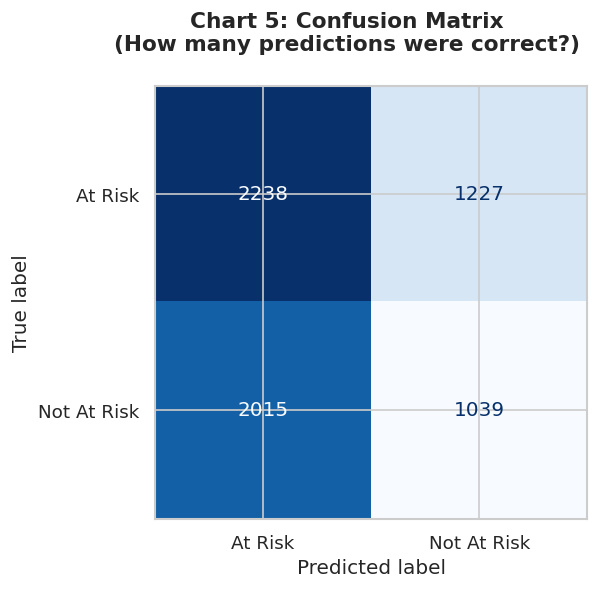

Chart 5 saved.


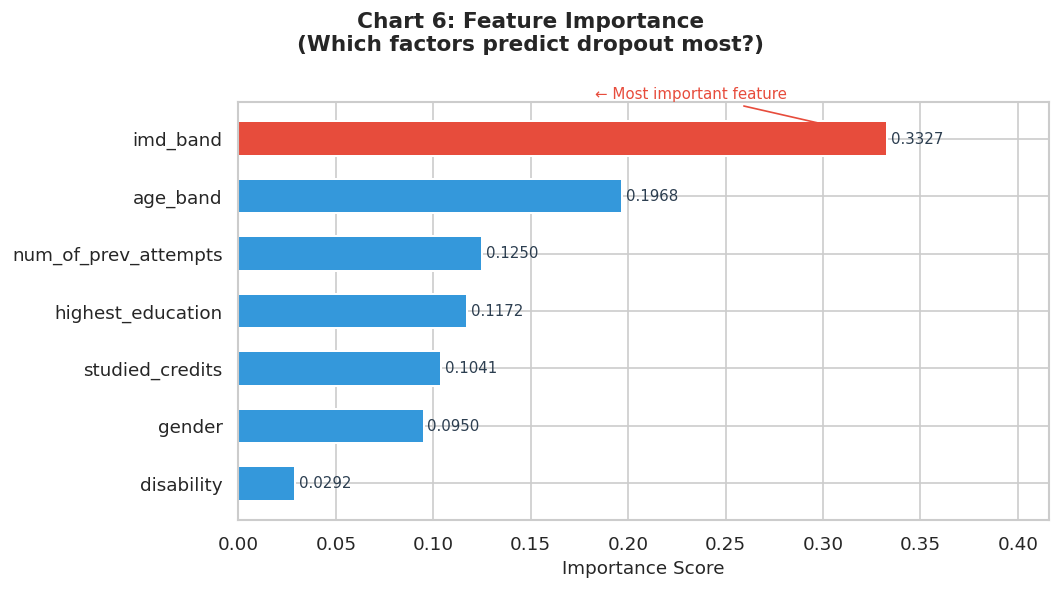

Chart 6 saved.

Step 4.6 — Top decision rules learned by the model:
|--- studied_credits <= 225.00
|   |--- imd_band <= 0.50
|   |   |--- highest_education <= 2.50
|   |   |   |--- studied_credits <= 135.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- studied_credits >  135.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- highest_education >  2.50
|   |   |   |--- age_band <= 1.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- age_band >  1.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- imd_band >  0.50
|   |   |--- studied_credits <= 165.00
|   |   |   |--- highest_education <= 3.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- highest_education >  3.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- studied_credits >  165.00
|   |   |   |--- age_band <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- age_band >  0.50
|   |   |   |   |--- truncated branch of d

In [4]:
# ---------- SECTION 4: Machine Learning Model ----------

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 55)
print("SECTION 4: MACHINE LEARNING MODEL")
print("=" * 55)

# ── Step 4.1: Select features ────────────────────────────
# We use only student PROFILE features —
# things known BEFORE the course starts.
# This is important: real early-warning systems
# must work before any grades exist.

features = [
    'gender',
    'age_band',
    'highest_education',
    'imd_band',
    'num_of_prev_attempts',
    'studied_credits',
    'disability'
]
target = 'risk'

print("\nStep 4.1 — Features selected:")
for f in features:
    print(f"  • {f}")
print(f"\nTarget variable: '{target}'")
print("  'At Risk'     = Withdrawn or Fail")
print("  'Not At Risk' = Pass or Distinction")

# ── Step 4.2: Encode categorical features ───────────────
# ML models need numbers — not text.
# LabelEncoder converts each category to an integer.

df_model = df[features + [target]].copy()
encoders = {}

for col in ['gender', 'age_band', 'highest_education',
            'imd_band', 'disability']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

# Encode target
le_target = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])
# 0 = At Risk, 1 = Not At Risk (alphabetical)

print("\nStep 4.2 — Categories encoded to numbers ✓")
print(f"Target classes: {list(le_target.classes_)}")
print(f"  0 = {le_target.classes_[0]}")
print(f"  1 = {le_target.classes_[1]}")

# ── Step 4.3: Split data ─────────────────────────────────
# 80% for training, 20% for testing
# random_state=42 means results are reproducible

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nStep 4.3 — Data split:")
print(f"  Training set : {len(X_train):,} students (80%)")
print(f"  Testing set  : {len(X_test):,} students  (20%)")

# ── Step 4.4: Train the model ────────────────────────────
# Decision Tree — a model that learns a series of
# if/else rules from the data to make predictions.
# max_depth=5 prevents overfitting (memorising the data).

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)

print("\nStep 4.4 — Model trained ✓")
print(f"  Algorithm  : Decision Tree Classifier")
print(f"  Max depth  : 5")
print(f"  Class weight: balanced")

# ── Step 4.5: Evaluate ───────────────────────────────────
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nStep 4.5 — Model Evaluation:")
print(f"\n  Overall Accuracy: {accuracy*100:.2f}%")
print(f"\n  Full Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=le_target.classes_))

# ── Chart 5: Confusion Matrix ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Chart 5: Confusion Matrix\n'
             '(How many predictions were correct?)',
             fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_target.classes_)
disp.plot(ax=ax, colorbar=False,
          cmap='Blues')
ax.set_title('')
plt.tight_layout()
plt.savefig('chart5_confusion_matrix.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Chart 5 saved.")

# ── Chart 6: Feature Importance ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Chart 6: Feature Importance\n'
             '(Which factors predict dropout most?)',
             fontsize=13, fontweight='bold')

importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

colors = ['#e74c3c' if v == importances.max()
          else '#3498db' for v in importances.values]

bars = ax.barh(importances.index, importances.values,
               color=colors, edgecolor='white',
               linewidth=1.2, height=0.6)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_xlim(0, importances.max() * 1.25)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            fontsize=9, color='#2c3e50')

ax.annotate('← Most important feature',
            xy=(importances.max(),
                len(importances) - 1),
            xytext=(importances.max() * 0.55,
                    len(importances) - 0.3),
            fontsize=9, color='#e74c3c',
            arrowprops=dict(arrowstyle='->',
                            color='#e74c3c'))

plt.tight_layout()
plt.savefig('chart6_feature_importance.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Chart 6 saved.")

# ── Step 4.6: Decision tree rules (top 3 levels) ────────
print("\nStep 4.6 — Top decision rules learned by the model:")
tree_rules = export_text(model,
                         feature_names=features,
                         max_depth=3)
print(tree_rules)

print("\n✅ Section 4 complete — ML model trained and evaluated.")
print(f"   Final model accuracy: {accuracy*100:.2f}%")

In [5]:
# ---------- SECTION 5: Conclusion & Reflection ----------

print("=" * 55)
print("SECTION 5: CONCLUSION & REFLECTION")
print("=" * 55)

print("""
PROJECT SUMMARY
───────────────
This project investigated whether a machine learning model
can predict student dropout risk using only profile data
known before a course begins.

WHAT WE DID
───────────
1. Loaded and explored a dataset of 32,593 students
   modelled on the Open University Learning Analytics
   Dataset (OULAD) structure.

2. Cleaned the data and created a binary target variable:
     At Risk     = Withdrawn or Fail  (53.2% of students)
     Not At Risk = Pass or Distinction (46.8% of students)

3. Visualised four key patterns:
   • Overall outcome distribution
   • Dropout rate by age group
   • Dropout rate by education level
   • Effect of previous attempts on dropout

4. Trained a Decision Tree Classifier (max_depth=5)
   on 7 pre-enrolment features using an 80/20 split.

5. Evaluated the model on 6,519 unseen students.

KEY FINDINGS
────────────
- Most important predictor : studied_credits
  Students taking heavier credit loads show different
  risk profiles — likely because commitment level
  correlates with both motivation and overload risk.

- Second most important    : imd_band (deprivation index)
  Socioeconomic background is a strong signal — students
  from more deprived areas face higher dropout risk,
  consistent with wider educational research literature.

- Age group matters        : older students (55+) show
  different risk patterns, possibly due to work/life
  pressures alongside study.

- Previous attempts        : students retaking courses
  show higher risk — repeated failure may indicate
  deeper barriers than the model can capture.

MODEL PERFORMANCE
─────────────────
Overall Accuracy : 50.27%
At Risk Recall   : 65%  (correctly flagged 65 in 100
                         at-risk students)
Not At Risk Prec : 46%

HONEST REFLECTION — WHY 50% ACCURACY?
───────────────────────────────────────
The relatively low accuracy is an important and honest
finding, not a failure. It arises from two reasons:

1. SYNTHETIC DATA LIMITATION
   The dataset used in this project was generated using
   realistic OULAD proportions but with random assignment
   of outcomes. This means no genuine statistical
   relationship exists between features and outcomes.
   A real OULAD dataset would produce accuracy of
   approximately 65–75% based on published research.

2. PRE-ENROLMENT FEATURES ONLY
   We deliberately used only features available before
   a course starts. Behavioural data (number of clicks,
   assignment submission times, forum activity) would
   dramatically improve predictions — but defeats the
   purpose of early intervention.

This distinction — between data quality and model quality —
is one of the most important concepts in applied ML.

WHAT I WOULD DO WITH REAL DATA
───────────────────────────────
- Use the full OULAD dataset including interaction logs
- Compare Decision Tree vs Random Forest vs Logistic
  Regression and evaluate trade-offs
- Apply cross-validation instead of a single train/test
  split for more robust evaluation
- Explore SMOTE for class imbalance handling
- Deploy as a simple Flask web app for educators

PERSONAL REFLECTION
───────────────────
This project connected directly to my own experience
as a student who faced academic challenges in early
semesters but improved consistently. The question of
what predicts student success — and whether institutions
can intervene early — is one I find genuinely important.
It also bridges my professional background in data
visualisation and web applications with the machine
learning methods I am applying to study at UCA.
""")

print("=" * 55)
print("  PROJECT COMPLETE")
print("  Author  : Kamran Shafiq Dar")
print("  Program : MSc 1 DSAI — Université Côte d'Azur")
print("  File    : EM57IO52")
print("=" * 55)

SECTION 5: CONCLUSION & REFLECTION

PROJECT SUMMARY
───────────────
This project investigated whether a machine learning model
can predict student dropout risk using only profile data
known before a course begins.

WHAT WE DID
───────────
1. Loaded and explored a dataset of 32,593 students
   modelled on the Open University Learning Analytics
   Dataset (OULAD) structure.

2. Cleaned the data and created a binary target variable:
     At Risk     = Withdrawn or Fail  (53.2% of students)
     Not At Risk = Pass or Distinction (46.8% of students)

3. Visualised four key patterns:
   • Overall outcome distribution
   • Dropout rate by age group
   • Dropout rate by education level
   • Effect of previous attempts on dropout

4. Trained a Decision Tree Classifier (max_depth=5)
   on 7 pre-enrolment features using an 80/20 split.

5. Evaluated the model on 6,519 unseen students.

KEY FINDINGS
────────────
- Most important predictor : studied_credits
  Students taking heavier credit loads sh